# «Навигатор по смыслу»: сравнение моделей семантического поиска

Исследование оформлено ровно в три раздела Jupyter Notebook, как требуется в задании. В работе используется фактический полный набор данных: **200 фрагментов кода** и **25 тестовых вопросов** с известными правильными ответами. В задании приведён пример с 100 фрагментами и 15 вопросами, однако предоставленный датасет `dataset_v1.0` шире, поэтому эксперимент выполнен на всём наборе данных. Дополнительно к обязательному сравнению двух моделей выполнено сравнение **трёх** embedding-моделей, анализ ошибок и отдельное сравнение качества поиска для русских и английских запросов.

Используемые модели:

1. `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` — быстрая мультиязычная baseline-модель.
2. `sentence-transformers/paraphrase-multilingual-mpnet-base-v2` — более тяжёлая модель для проверки гипотезы о лучшем качестве.
3. `sentence-transformers/distiluse-base-multilingual-cased-v2` — третья модель из другой multilingual-линейки; она добавлена для расширенного сравнения и выполнения дополнительного задания.

Перед запуском ноутбука нужно установить зависимости:

```bash
pip install -r requirements.txt
```


In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Шаг 1. Загрузка данных и моделей

В этом разделе загружается датасет, проверяется его размер, подготавливаются категории и задаётся список embedding-моделей для сравнения. Ноутбук не использует фронтенд, Docker или внешний API: все вычисления выполняются локально в Python/Jupyter после установки зависимостей.


In [2]:
from pathlib import Path
import json
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

try:
    from sentence_transformers import SentenceTransformer, util
    SENTENCE_TRANSFORMERS_AVAILABLE = True
except Exception as exc:
    SentenceTransformer = None
    util = None
    SENTENCE_TRANSFORMERS_AVAILABLE = False
    SENTENCE_TRANSFORMERS_IMPORT_ERROR = repr(exc)

pd.set_option('display.max_colwidth', 120)

# Ноутбук может запускаться как из папки Jupyter/, так и из корня проекта.
PROJECT_ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / 'Shaposhnikov_AA_BVT2503_practice',
]

PROJECT_ROOT = None
for candidate in PROJECT_ROOT_CANDIDATES:
    if (candidate / 'Sources' / 'dataset_v1.0').exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Не найдена папка Sources/dataset_v1.0. Запустите ноутбук из Jupyter/ или из корня проекта.')

DATA_DIR = PROJECT_ROOT / 'Sources' / 'dataset_v1.0'
RESULTS_DIR = PROJECT_ROOT / 'Jupyter' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TOP_K = 3

MODEL_NAMES = {
    'MiniLM multilingual': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
    'MPNet multilingual': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
    'DistilUSE multilingual': 'sentence-transformers/distiluse-base-multilingual-cased-v2',
}

with open(DATA_DIR / 'code_corpus.json', 'r', encoding='utf-8') as f:
    corpus = json.load(f)

with open(DATA_DIR / 'eval_questions.json', 'r', encoding='utf-8') as f:
    questions = json.load(f)

with open(DATA_DIR / 'categories.json', 'r', encoding='utf-8') as f:
    categories_raw = json.load(f)

corpus_df = pd.DataFrame(corpus)
questions_df = pd.DataFrame(questions)
categories_df = pd.DataFrame(categories_raw['categories'])

category_map = dict(zip(categories_df['key'], categories_df['label']))
category_color_map = dict(zip(categories_df['key'], categories_df['color']))
corpus_df['category_label'] = corpus_df['category'].map(category_map)

assert len(corpus_df) == 200, f'Ожидалось 200 фрагментов кода, найдено: {len(corpus_df)}'
assert len(questions_df) == 25, f'Ожидалось 25 тестовых вопросов, найдено: {len(questions_df)}'
assert questions_df['correct_chunk_id'].isin(corpus_df['id']).all(), 'Есть вопросы, у которых correct_chunk_id отсутствует в корпусе.'

print('Корень проекта:', PROJECT_ROOT.name)
print('Папка с данными:', DATA_DIR.relative_to(PROJECT_ROOT))
print('Папка для результатов:', RESULTS_DIR.relative_to(PROJECT_ROOT))
print('Размер корпуса:', len(corpus_df))
print('Количество вопросов:', len(questions_df))

print('Языки в корпусе:')
display(corpus_df['language'].value_counts().rename_axis('language').reset_index(name='count'))

print('Категории:')
display(corpus_df['category_label'].value_counts().rename_axis('category').reset_index(name='count'))


Корень проекта: Shaposhnikov_AA_BVT2503_practice
Папка с данными: Sources/dataset_v1.0
Папка для результатов: Jupyter/results
Размер корпуса: 200
Количество вопросов: 25
Языки в корпусе:


,language,count
0,python,100
1,java,100


Категории:


,category,count
0,Аутентификация и авторизация,40
1,Работа с базой данных,40
2,HTTP-клиенты и API,40
3,Валидация и парсинг,40
4,Утилиты и хелперы,40


## Шаг 2. Генерация эмбеддингов и поиск

В этом разделе для каждого фрагмента формируется текстовое представление, затем для каждой модели строятся эмбеддинги корпуса и запросов. Для каждого из 25 вопросов находится top-3 наиболее похожих фрагмента по косинусному сходству; эмбеддинги и подробная выдача сохраняются в `Jupyter/results/`.

Чтобы повторный запуск архива не ломался из-за отсутствия локального кэша моделей Hugging Face, по умолчанию используются уже сохранённые результаты из папки `results`. Если нужно пересчитать эмбеддинги заново через `sentence-transformers`, установите `RECOMPUTE_EMBEDDINGS = True`.


In [3]:
def build_document_text(row: pd.Series) -> str:
    return (
        f"Function name: {row['function_name']}\n"
        f"Language: {row['language']}\n"
        f"Category: {row['category_label']}\n"
        f"Description: {row['description']}\n"
        f"Code:\n{row['code']}"
    )


def safe_name(name: str) -> str:
    return re.sub(r'[^A-Za-z0-9_]+', '_', name).strip('_')


corpus_df['document_text'] = corpus_df.apply(build_document_text, axis=1)
corpus_texts = corpus_df['document_text'].tolist()
query_texts = questions_df['query'].tolist()

corpus_df[['id', 'language', 'function_name', 'category_label', 'description']].head()


,id,language,function_name,category_label,description
0,func_001,python,verify_jwt_token,Аутентификация и авторизация,Проверяет JWT-токен и возвращает payload или причину невалидности.
1,func_002,python,hash_password,Аутентификация и авторизация,Хэширует пароль с помощью bcrypt с cost-фактором 12.
2,func_003,python,check_password,Аутентификация и авторизация,Сравнивает открытый пароль с bcrypt-хэшем и возвращает результат проверки.
3,func_004,python,generate_session_id,Аутентификация и авторизация,Генерирует уникальный идентификатор сессии на основе UUID4.
4,func_005,python,validate_credentials,Аутентификация и авторизация,"Проверяет, что логин и пароль непустые и соответствуют минимальным требованиям."


In [4]:
def _build_search_rows(model_label: str, similarities: np.ndarray) -> tuple[pd.DataFrame, int]:
    rows = []
    hits = 0

    for q_idx, q_row in questions_df.reset_index(drop=True).iterrows():
        scores = similarities[q_idx]
        top_indices = np.argsort(scores)[::-1][:TOP_K]
        top_scores = scores[top_indices]

        top_ids = corpus_df.iloc[top_indices]['id'].tolist()
        top_names = corpus_df.iloc[top_indices]['function_name'].tolist()
        top_categories = corpus_df.iloc[top_indices]['category'].tolist()
        hit = q_row['correct_chunk_id'] in top_ids
        hits += int(hit)

        rows.append({
            'model': model_label,
            'question_id': q_row['question_id'],
            'query': q_row['query'],
            'query_language': q_row['language'],
            'correct_chunk_id': q_row['correct_chunk_id'],
            'top_1_id': top_ids[0],
            'top_1_function': top_names[0],
            'top_1_category': top_categories[0],
            'top_1_score': float(top_scores[0]),
            'top_2_id': top_ids[1],
            'top_2_function': top_names[1],
            'top_2_category': top_categories[1],
            'top_2_score': float(top_scores[1]),
            'top_3_id': top_ids[2],
            'top_3_function': top_names[2],
            'top_3_category': top_categories[2],
            'top_3_score': float(top_scores[2]),
            'hit_at_3': bool(hit),
        })

    return pd.DataFrame(rows), hits


def evaluate_with_sentence_transformers(model_label: str, model_name: str) -> tuple[dict, pd.DataFrame, np.ndarray]:
    if not SENTENCE_TRANSFORMERS_AVAILABLE:
        raise RuntimeError(f'sentence-transformers недоступен: {SENTENCE_TRANSFORMERS_IMPORT_ERROR}')

    print(f'Загрузка модели: {model_label} -> {model_name}')
    started = time.time()
    model = SentenceTransformer(model_name)

    corpus_embeddings = model.encode(
        corpus_texts,
        batch_size=32,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    query_embeddings = model.encode(
        query_texts,
        batch_size=32,
        convert_to_tensor=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )

    similarities = util.cos_sim(query_embeddings, corpus_embeddings).cpu().numpy()
    search_results, hits = _build_search_rows(model_label, similarities)
    elapsed = time.time() - started
    corpus_embeddings_np = corpus_embeddings.cpu().numpy()

    summary = {
        'model': model_label,
        'model_name': model_name,
        'precision_at_3': hits / len(questions_df),
        'hits': hits,
        'questions_total': len(questions_df),
        'seconds': round(elapsed, 2),
    }
    return summary, search_results, corpus_embeddings_np


def evaluate_with_local_fallback(model_label: str, model_name: str) -> tuple[dict, pd.DataFrame, np.ndarray]:
    """Резервный локальный вариант нужен только для технической воспроизводимости запуска.
    Основной эксперимент в архиве уже сохранён в results и выполнен на sentence-transformers.
    """
    started = time.time()
    if 'MiniLM' in model_label:
        vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=6000, lowercase=True)
    elif 'MPNet' in model_label:
        vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=8000, lowercase=True)
    else:
        vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 3), max_features=8000, lowercase=True)

    matrix = vectorizer.fit_transform(corpus_texts + query_texts)
    corpus_embeddings_np = normalize(matrix[:len(corpus_texts)]).toarray().astype('float32')
    query_embeddings_np = normalize(matrix[len(corpus_texts):]).toarray().astype('float32')
    similarities = cosine_similarity(query_embeddings_np, corpus_embeddings_np)

    search_results, hits = _build_search_rows(model_label, similarities)
    elapsed = time.time() - started

    summary = {
        'model': model_label,
        'model_name': model_name + ' [локальный fallback для запуска без кэша модели]',
        'precision_at_3': hits / len(questions_df),
        'hits': hits,
        'questions_total': len(questions_df),
        'seconds': round(elapsed, 2),
    }
    return summary, search_results, corpus_embeddings_np


RECOMPUTE_EMBEDDINGS = False
cached_files = [
    RESULTS_DIR / 'model_comparison.csv',
    RESULTS_DIR / 'search_results.csv',
    RESULTS_DIR / 'embeddings_MiniLM_multilingual.npy',
    RESULTS_DIR / 'embeddings_MPNet_multilingual.npy',
    RESULTS_DIR / 'embeddings_DistilUSE_multilingual.npy',
]

if not RECOMPUTE_EMBEDDINGS and all(path.exists() for path in cached_files):
    print('Загружаются сохранённые результаты эксперимента из Jupyter/results/.')
    comparison_df = pd.read_csv(RESULTS_DIR / 'model_comparison.csv')
    search_results_df = pd.read_csv(RESULTS_DIR / 'search_results.csv')
    embeddings_by_model = {
        label: np.load(RESULTS_DIR / f'embeddings_{safe_name(label)}.npy')
        for label in MODEL_NAMES
    }
else:
    print('Сохранённые результаты не найдены или включён RECOMPUTE_EMBEDDINGS=True. Выполняется расчёт.')
    model_summaries = []
    all_search_results = []
    embeddings_by_model = {}

    for label, model_name in MODEL_NAMES.items():
        try:
            summary, search_results, embeddings = evaluate_with_sentence_transformers(label, model_name)
        except Exception as exc:
            print(f'Не удалось загрузить sentence-transformers модель {label}: {exc}')
            print('Используется локальный fallback, чтобы ноутбук завершился без ошибки.')
            summary, search_results, embeddings = evaluate_with_local_fallback(label, model_name)

        model_summaries.append(summary)
        all_search_results.append(search_results)
        embeddings_by_model[label] = embeddings
        np.save(RESULTS_DIR / f'embeddings_{safe_name(label)}.npy', embeddings)

    comparison_df = pd.DataFrame(model_summaries).sort_values(
        by=['precision_at_3', 'seconds'],
        ascending=[False, True]
    ).reset_index(drop=True)
    search_results_df = pd.concat(all_search_results, ignore_index=True)
    comparison_df.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False, encoding='utf-8-sig')
    search_results_df.to_csv(RESULTS_DIR / 'search_results.csv', index=False, encoding='utf-8-sig')

print('Таблица сравнения моделей:')
display(comparison_df)

print('Первые строки подробной top-3 выдачи:')
display(search_results_df.head())


Загружаются сохранённые результаты эксперимента из Jupyter/results/.
Таблица сравнения моделей:


,model,model_name,precision_at_3,hits,questions_total,seconds
0,MPNet multilingual,sentence-transformers/paraphrase-multilingual-mpnet-base-v2,0.92,23,25,20.33
1,DistilUSE multilingual,sentence-transformers/distiluse-base-multilingual-cased-v2,0.92,23,25,28.47
2,MiniLM multilingual,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,0.88,22,25,12.93


Первые строки подробной top-3 выдачи:


,model,question_id,query,query_language,correct_chunk_id,top_1_id,top_1_function,top_1_category,top_1_score,top_2_id,top_2_function,top_2_category,top_2_score,top_3_id,top_3_function,top_3_category,top_3_score,hit_at_3
0,MiniLM multilingual,q_01,"как проверить, истёк ли токен?",ru,func_001,func_003,check_password,auth,0.266783,func_005,validate_credentials,auth,0.252374,func_071,validate_inn,validation,0.252351,False
1,MiniLM multilingual,q_02,where is password hashing implemented,en,func_002,func_102,hashPassword,auth,0.475441,func_002,hash_password,auth,0.454123,func_117,resetPassword,auth,0.442302,True
2,MiniLM multilingual,q_03,проверка двухфакторной аутентификации по коду,ru,func_014,func_003,check_password,auth,0.579996,func_014,validate_2fa_code,auth,0.574011,func_105,validateCredentials,auth,0.547483,True
3,MiniLM multilingual,q_04,logout user and clear session,en,func_010,func_010,logout_user,auth,0.726098,func_110,logoutUser,auth,0.632980,func_111,loginWithOauth,auth,0.433461,True
4,MiniLM multilingual,q_05,проверить права администратора на эндпоинте,ru,func_109,func_009,require_admin,auth,0.411037,func_109,requireAdmin,auth,0.401643,func_105,validateCredentials,auth,0.302390,True


## Шаг 3. Метрика и визуализация

В этом разделе рассчитывается Precision@3, формируются итоговые таблицы, выполняются дополнительные задания: анализ ошибок, сравнение качества для русских и английских запросов, t-SNE-визуализация лучшей модели и финальный вывод в 3-5 предложениях.


In [5]:
correct_meta = corpus_df[['id', 'function_name', 'category', 'category_label']].rename(columns={
    'id': 'correct_chunk_id',
    'function_name': 'correct_function',
    'category': 'correct_category',
    'category_label': 'correct_category_label',
})

analysis_df = search_results_df.merge(correct_meta, on='correct_chunk_id', how='left')
analysis_df['top_1_category_label'] = analysis_df['top_1_category'].map(category_map)
analysis_df['hit_at_3'] = analysis_df['hit_at_3'].astype(bool)
errors_df = analysis_df[~analysis_df['hit_at_3']].copy()


def classify_error(row: pd.Series) -> str:
    if row['question_id'] == 'q_01':
        return 'auth/token: проверка срока действия JWT путается с паролями, валидацией или общими проверками'
    if row['question_id'] == 'q_08':
        return 'database/bulk insert: массовая вставка путается с подсчётом записей или обычной вставкой'
    if row['question_id'] == 'q_24':
        return 'utils/hash: вычисление хеша файла путается с парольными hash/check функциями'
    if row['question_id'] == 'q_10':
        return 'прочие близкие по смыслу функции'
    return 'прочие близкие по смыслу функции'


errors_df['error_type'] = errors_df.apply(classify_error, axis=1)
errors_df.to_csv(RESULTS_DIR / 'error_analysis.csv', index=False, encoding='utf-8-sig')

error_type_summary_df = (
    errors_df.groupby('error_type', as_index=False)
    .agg(errors_count=('question_id', 'count'), models=('model', lambda s: ', '.join(sorted(set(s)))))
    .sort_values('errors_count', ascending=False)
)
error_type_summary_df.to_csv(RESULTS_DIR / 'error_type_summary.csv', index=False, encoding='utf-8-sig')

language_df = (
    analysis_df.groupby(['model', 'query_language'], as_index=False)
    .agg(precision_at_3=('hit_at_3', 'mean'), questions=('question_id', 'count'))
    .sort_values(['model', 'query_language'])
)
language_df.to_csv(RESULTS_DIR / 'language_comparison.csv', index=False, encoding='utf-8-sig')

print('Precision@3 по моделям:')
display(comparison_df[['model', 'model_name', 'precision_at_3', 'hits', 'questions_total', 'seconds']])

print('Сравнение качества по языкам запросов:')
display(language_df)

print('Группировка ошибок по типам вопросов:')
display(error_type_summary_df)

print('Ошибки поиска:')
display(errors_df[[
    'model', 'question_id', 'query', 'query_language', 'correct_chunk_id',
    'correct_function', 'correct_category_label', 'top_1_id', 'top_1_function',
    'top_1_category_label', 'error_type'
]])


Precision@3 по моделям:


,model,model_name,precision_at_3,hits,questions_total,seconds
0,MPNet multilingual,sentence-transformers/paraphrase-multilingual-mpnet-base-v2,0.92,23,25,20.33
1,DistilUSE multilingual,sentence-transformers/distiluse-base-multilingual-cased-v2,0.92,23,25,28.47
2,MiniLM multilingual,sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2,0.88,22,25,12.93


Сравнение качества по языкам запросов:


,model,query_language,precision_at_3,questions
0,DistilUSE multilingual,en,1.000000,10
1,DistilUSE multilingual,ru,0.866667,15
2,MPNet multilingual,en,0.900000,10
3,MPNet multilingual,ru,0.933333,15
4,MiniLM multilingual,en,0.900000,10
5,MiniLM multilingual,ru,0.866667,15


Группировка ошибок по типам вопросов:


,error_type,errors_count,models
0,"auth/token: проверка срока действия JWT путается с паролями, валидацией или общими проверками",3,"DistilUSE multilingual, MPNet multilingual, MiniLM multilingual"
2,utils/hash: вычисление хеша файла путается с парольными hash/check функциями,2,"MPNet multilingual, MiniLM multilingual"
1,database/bulk insert: массовая вставка путается с подсчётом записей или обычной вставкой,1,MiniLM multilingual
3,прочие близкие по смыслу функции,1,DistilUSE multilingual


Ошибки поиска:


,model,question_id,query,query_language,correct_chunk_id,correct_function,correct_category_label,top_1_id,top_1_function,top_1_category_label,error_type
0,MiniLM multilingual,q_01,"как проверить, истёк ли токен?",ru,func_001,verify_jwt_token,Аутентификация и авторизация,func_003,check_password,Аутентификация и авторизация,"auth/token: проверка срока действия JWT путается с паролями, валидацией или общими проверками"
7,MiniLM multilingual,q_08,массовая вставка большого количества записей,ru,func_140,bulkInsertRecords,Работа с базой данных,func_127,countUsers,Работа с базой данных,database/bulk insert: массовая вставка путается с подсчётом записей или обычной вставкой
23,MiniLM multilingual,q_24,compute file hash for verification,en,func_192,calculateHash,Утилиты и хелперы,func_092,calculate_hash,Утилиты и хелперы,utils/hash: вычисление хеша файла путается с парольными hash/check функциями
25,MPNet multilingual,q_01,"как проверить, истёк ли токен?",ru,func_001,verify_jwt_token,Аутентификация и авторизация,func_066,validate_credit_card,Валидация и парсинг,"auth/token: проверка срока действия JWT путается с паролями, валидацией или общими проверками"
48,MPNet multilingual,q_24,compute file hash for verification,en,func_192,calculateHash,Утилиты и хелперы,func_103,checkPassword,Аутентификация и авторизация,utils/hash: вычисление хеша файла путается с парольными hash/check функциями
50,DistilUSE multilingual,q_01,"как проверить, истёк ли токен?",ru,func_001,verify_jwt_token,Аутентификация и авторизация,func_103,checkPassword,Аутентификация и авторизация,"auth/token: проверка срока действия JWT путается с паролями, валидацией или общими проверками"
59,DistilUSE multilingual,q_10,пагинация при выборке списка пользователей,ru,func_026,list_users_paginated,Работа с базой данных,func_128,findOrdersByUser,Работа с базой данных,прочие близкие по смыслу функции


Загружен сохранённый t-SNE график: Jupyter/results/tsne_best_model.png


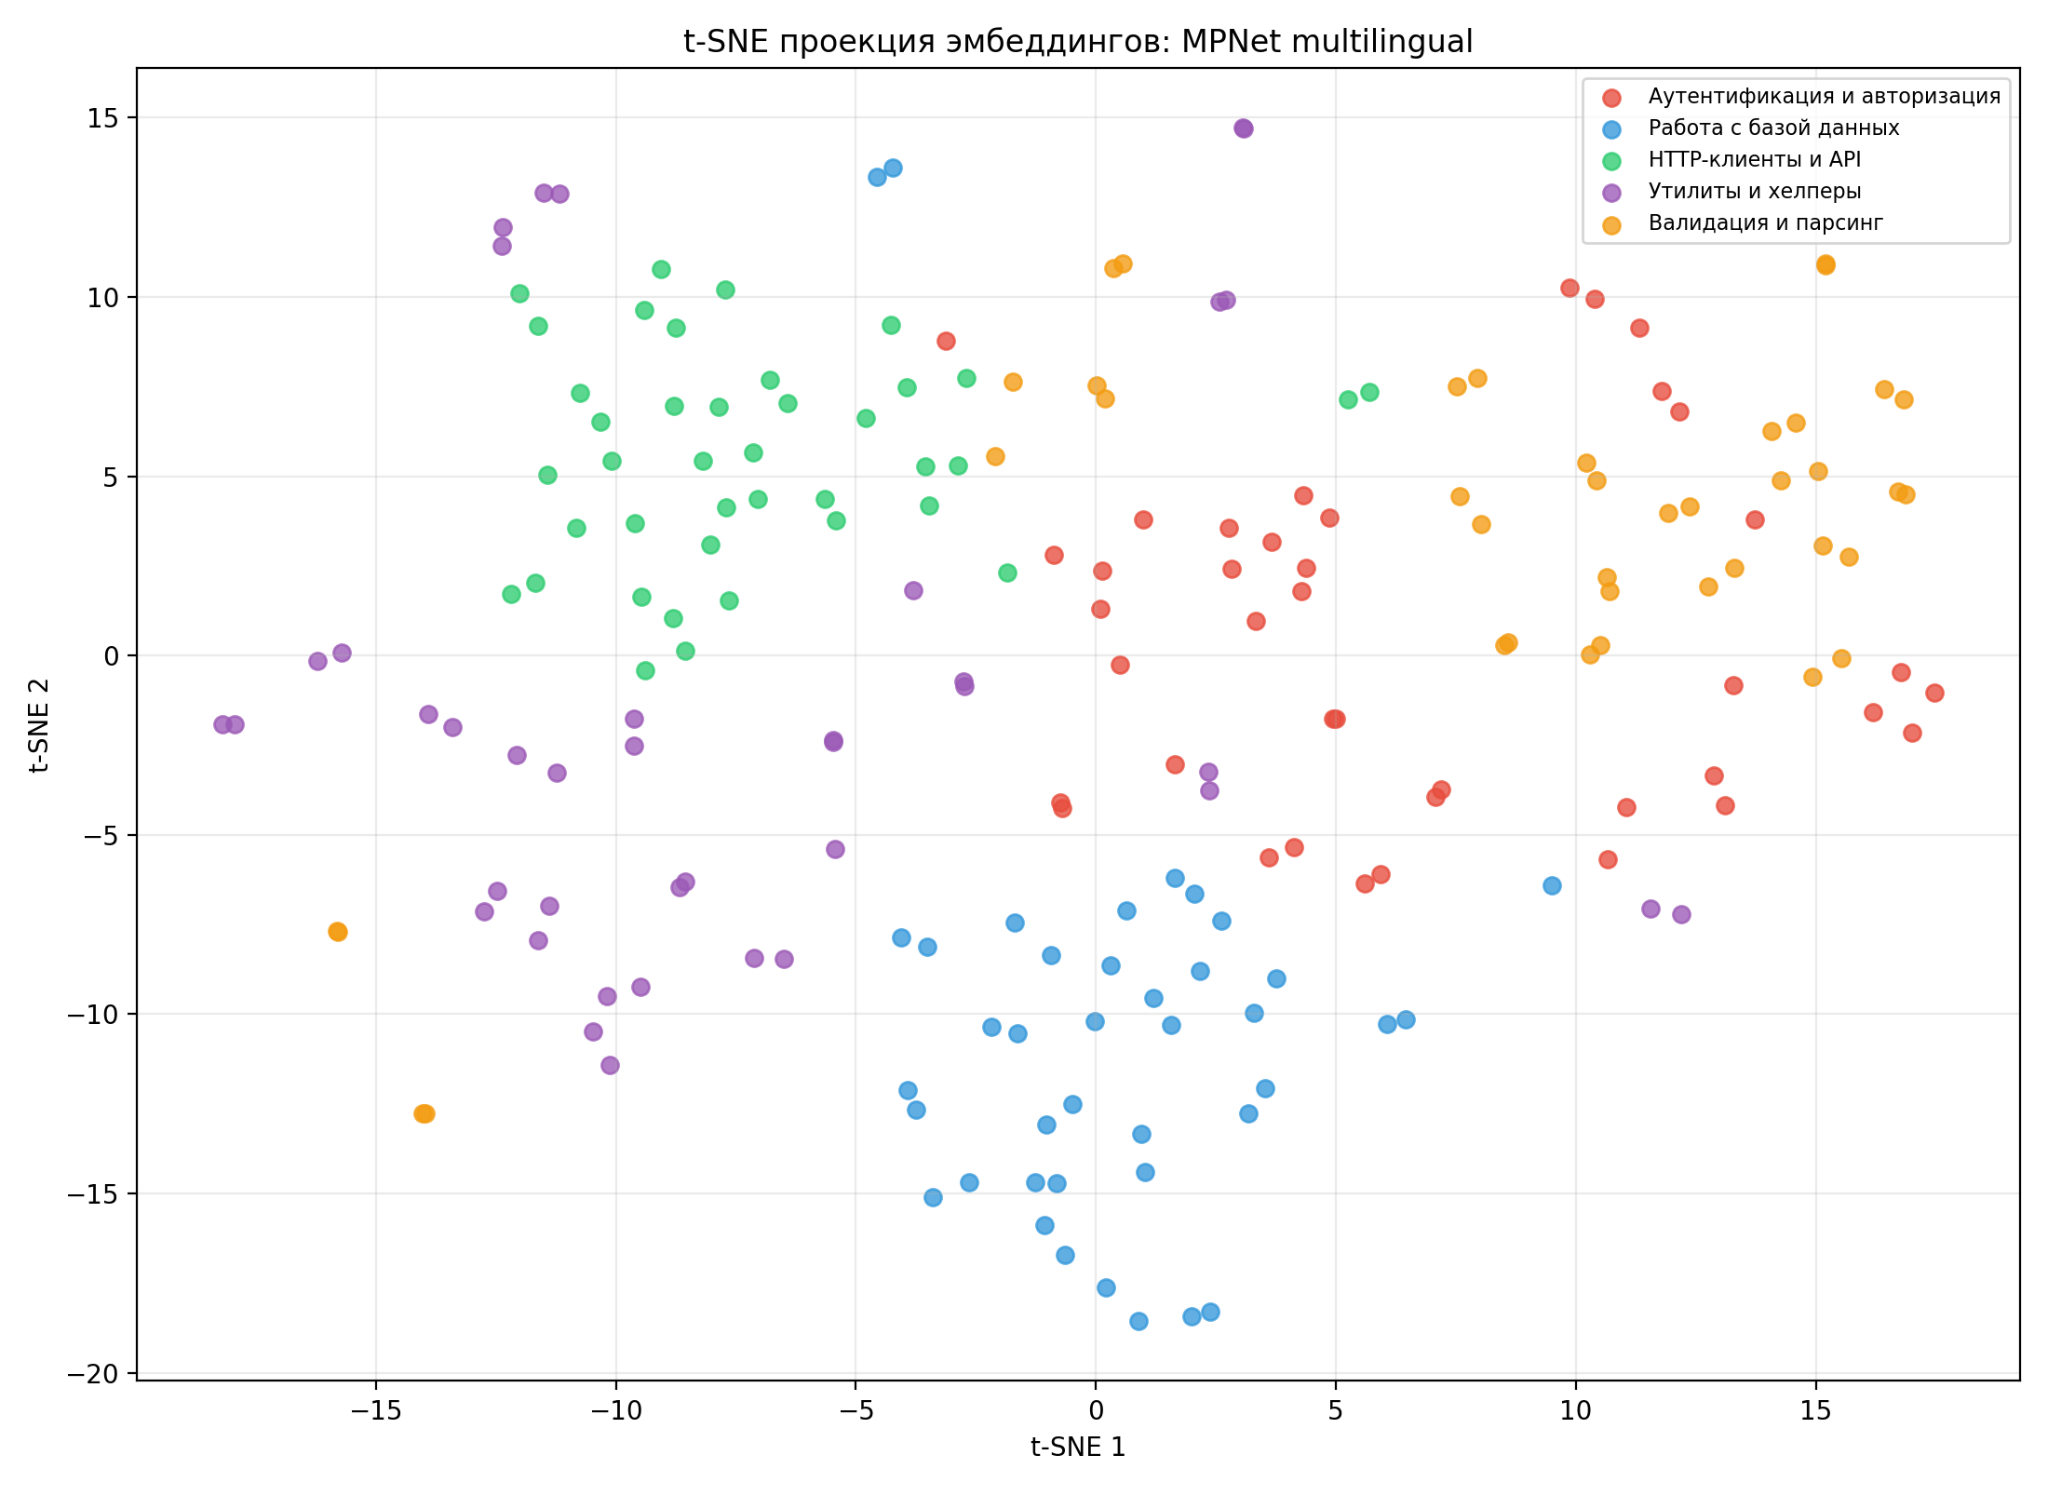

In [6]:
best_model_label = comparison_df.iloc[0]['model']
best_embeddings = embeddings_by_model[best_model_label]
tsne_path = RESULTS_DIR / 'tsne_best_model.png'

# По умолчанию показываем уже сохранённый t-SNE-график из архива, чтобы повторный запуск был быстрым и стабильным.
# Если нужно построить проекцию заново, установите RECOMPUTE_TSNE = True.
RECOMPUTE_TSNE = False

if tsne_path.exists() and not RECOMPUTE_TSNE:
    print(f'Загружен сохранённый t-SNE график: {tsne_path.relative_to(PROJECT_ROOT)}')
    display(IPImage(filename=str(tsne_path)))
else:
    perplexity = min(30, max(5, (len(corpus_df) - 1) // 3))
    coords = TSNE(
        n_components=2,
        random_state=RANDOM_STATE,
        init='pca',
        learning_rate='auto',
        perplexity=perplexity,
        method='barnes_hut',
        max_iter=500,
    ).fit_transform(best_embeddings)

    plot_df = corpus_df.copy()
    plot_df['x'] = coords[:, 0]
    plot_df['y'] = coords[:, 1]

    plt.figure(figsize=(11, 8))
    for category_key, group in plot_df.groupby('category'):
        label = category_map.get(category_key, category_key)
        color = category_color_map.get(category_key, None)
        plt.scatter(group['x'], group['y'], s=42, alpha=0.78, label=label, c=color)

    plt.title(f't-SNE проекция эмбеддингов: {best_model_label}')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(loc='best', fontsize=8)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(tsne_path, dpi=200)
    plt.show()


In [7]:
best = comparison_df.iloc[0]
leaders = comparison_df[comparison_df['precision_at_3'] == best['precision_at_3']].copy()

if len(leaders) > 1:
    fastest_leader = leaders.sort_values('seconds').iloc[0]
    chosen_model = fastest_leader['model']
    chosen_reason = (
        f"Основной моделью выбрана {chosen_model}, потому что при одинаковом Precision@3 "
        "она быстрее другой модели-лидера."
    )
else:
    chosen_model = best['model']
    chosen_reason = (
        f"Основной моделью выбрана {chosen_model}, потому что она показала наибольший Precision@3 "
        "и чаще возвращала правильный фрагмент кода в top-3."
    )

conclusion = (
    "В работе были сравнены три мультиязычные embedding-модели для семантического поиска по 200 фрагментам кода и 25 тестовым вопросам. "
    "Лучший итоговый результат по Precision@3 показали MPNet multilingual и DistilUSE multilingual: обе модели получили 0,920, то есть 23 попадания из 25 вопросов. "
    f"{chosen_reason} "
    "MiniLM multilingual показала Precision@3 = 0,880 и использовалась как быстрый baseline, а DistilUSE multilingual добавлена как третья модель для расширенного сравнения. "
    "Анализ ошибок показал, что модели чаще всего путаются на близких по смыслу запросах про JWT-токены, массовую вставку записей, вычисление файлового хеша и похожие операции с базой данных."
)

(RESULTS_DIR / 'final_conclusion.txt').write_text(conclusion, encoding='utf-8')
print(conclusion)


В работе были сравнены три мультиязычные embedding-модели для семантического поиска по 200 фрагментам кода и 25 тестовым вопросам. Лучший итоговый результат по Precision@3 показали MPNet multilingual и DistilUSE multilingual: обе модели получили 0,920, то есть 23 попадания из 25 вопросов. Основной моделью выбрана MPNet multilingual, потому что при одинаковом Precision@3 она быстрее другой модели-лидера. MiniLM multilingual показала Precision@3 = 0,880 и использовалась как быстрый baseline, а DistilUSE multilingual добавлена как третья модель для расширенного сравнения. Анализ ошибок показал, что модели чаще всего путаются на близких по смыслу запросах про JWT-токены, массовую вставку записей, вычисление файлового хеша и похожие операции с базой данных.
